In [1]:
%run data_prep.ipynb 

In [2]:
df.head()

,status,goal,pledged,funded percentage,backers,levels,updates,comments,duration,category_Comics,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,funded_month
0,successful,10500.0,11545.0,1.099524,66,7,10,2,30.00,0,...,0,0,0,0,0,0,0,0,0,8
1,failed,4000.0,20.0,0.005000,2,5,6,0,47.18,0,...,0,0,0,0,0,0,0,0,0,8
3,successful,6000.0,6535.0,1.089167,100,13,4,0,32.22,0,...,0,0,0,0,0,0,0,0,0,4
4,failed,3500.0,0.0,0.000000,0,6,2,0,30.00,0,...,0,0,0,0,0,0,0,0,0,6
5,successful,3500.0,3582.0,1.023331,39,7,8,0,21.43,0,...,0,0,0,0,0,0,0,0,0,6


In [3]:
X_train

,goal,levels,updates,comments,duration,category_Comics,category_Dance,category_Design,category_Fashion,category_Film & Video,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,funded_month
12159,15000.0,18,8,8,30.00,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,3
13259,10000.0,9,6,5,90.00,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,6
25430,500.0,5,1,2,28.17,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
10034,3300.0,8,3,0,38.52,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
23510,15000.0,14,11,9,33.01,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7639,1000.0,9,0,0,50.97,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3
6492,5000.0,7,4,1,30.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
8171,30000.0,6,1,0,30.00,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,8
26869,3500.0,6,2,10,30.00,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,5


In [4]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder  
from sklearn.ensemble import RandomForestClassifier as Ran

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = Ran(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))


Baseline Accuracy: 0.839081653854145


In [5]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Confusion Matrix:
 [[3569  842]
 [ 707 4508]]
Precision: 0.8389700430595407
Recall: 0.839081653854145
F1 Score: 0.8388593916595173


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10, 20],        
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 2, 4],         
    'max_features': ['sqrt', 'log2']       
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.8462499430394168


In [7]:
best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.8446914606274672
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      4411
           1       0.84      0.88      0.86      5215

    accuracy                           0.84      9626
   macro avg       0.84      0.84      0.84      9626
weighted avg       0.84      0.84      0.84      9626



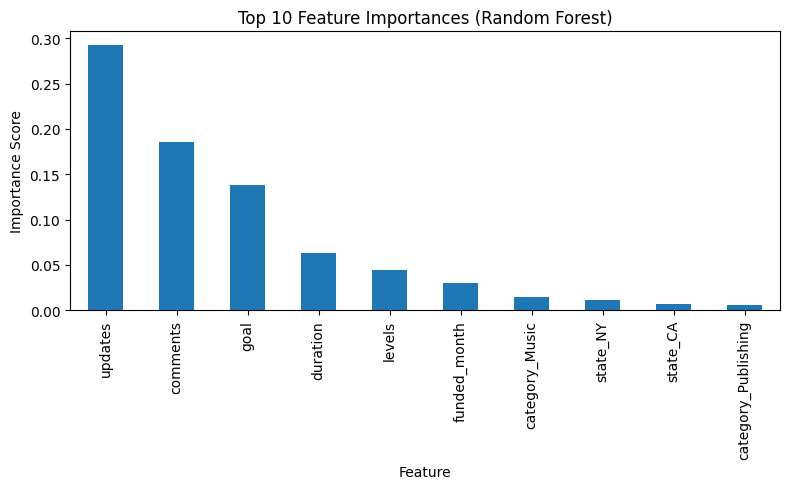

In [9]:
import matplotlib.pyplot as plt

best_rf = grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns)

top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


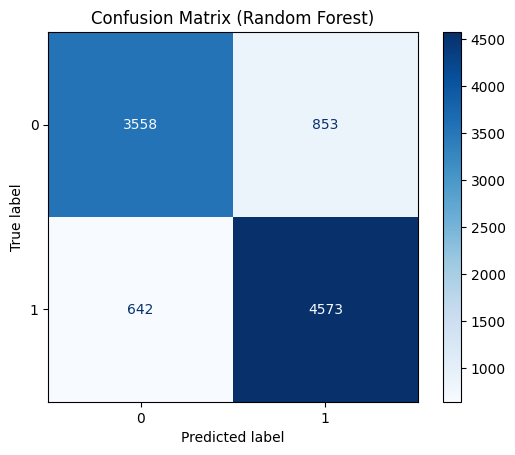

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.show()